# Stages 5: Comprehensive Baseline + DistilBERT Analysis

**Master notebook combining baseline models (Stage 5) and DistilBERT fine-tuning (Stage 6) in a unified, reproducible pipeline.**

## Overview

This notebook trains **five text classification models** on notification Ã— product Ã— exporter data:

1. **Country-only** (no text): baseline
2. **Text-only (TF-IDF)**: pure text signal  
3. **Text + Country (TF-IDF)**: text with exporter fixed effects
4. **Embeddings + Country (SBERT)**: semantic embeddings + exporter FE
5. **DistilBERT fine-tuning**: deep transformer with class weighting

**Data split (notification-level to prevent leakage):**
- **Pretrain pool**: 2010â€“2018
- **Bridge** (optional): 2019
- **Fine-tune / baseline train**: 2020â€“2023
- **Final test (unseen)**: 2024â€“2025

**Output**: standardized predictions, metrics tables, and model comparison plots for seamless downstream analysis.

## Section 1: Setup and Reproducibility

Set random seeds and deterministic settings for reproducible results across all models.

In [ ]:
# ============================================================================
# COLAB GPU T4 OPTIMIZATION - Enhanced Setup for GPU-Heavy Training
# ============================================================================
import os
import sys

# Detect Colab environment
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ or "google.colab" in sys.modules
if not IN_COLAB:
    try:
        from google.colab import drive
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

print(f"{'🔵 COLAB GPU MODE' if IN_COLAB else '🔷 LOCAL MODE'}")

# T4 GPU Specific Optimizations
if IN_COLAB:
    # Set memory growth to prevent OOM errors
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Reduce TF logging
    
    # Optimize for T4 (16GB VRAM)
    print("\n T4 GPU Configuration:")
    print("  • 16GB VRAM available")
    print("  • Batch size recommendations:")
    print("    - DistilBERT: 16-32 (memory-constrained)")
    print("    - TF-IDF/Sklearn: Up to 256")
    print("  • Training time: DistilBERT ~10-15 min/epoch on 6k samples")
    print("  • Watch for OOM errors - reduce batch_size if needed")


In [1]:
import os
import warnings
import random

# Reproducibility: set seeds
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

warnings.filterwarnings('ignore', category=FutureWarning)

print(f"âœ“ Random seed set to {SEED}")
print(f"âœ“ Deterministic behavior enabled")

âœ“ Random seed set to 42
âœ“ Deterministic behavior enabled


## Section 2: Imports and Environment Checks

Import all shared libraries and validate package versions and device availability.

In [2]:
# Install transformers and optional dependencies if needed
try:
    import torch
    import transformers
except ImportError:
    print("Installing transformers and related packages...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", 
                          "transformers==4.45.0", "datasets", "accelerate",
                          "numpy>=2.0,<2.1", "scipy>=1.13,<1.16", "scikit-learn>=1.6,<1.8"])

# Core data & ML libraries
import numpy as np
import pandas as pd
import time
from pathlib import Path

# Sklearn for baseline models
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report
)
from scipy.sparse import hstack, csr_matrix

# PyTorch & Transformers for DistilBERT
import torch
from torch.nn import BCEWithLogitsLoss
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, 
    EarlyStoppingCallback, TrainerCallback, 
    set_seed
)

# Plotting (optional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    PLOTTING_AVAILABLE = True
except ImportError:
    PLOTTING_AVAILABLE = False

# Optional semantic embeddings
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except ImportError:
    SBERT_AVAILABLE = False
    print("âš  sentence-transformers not installed. Skipping SBERT model.")

# Google Colab mount (if applicable)
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "COLAB_GPU" in os.environ
if IN_COLAB:
    try:
        from google.colab import drive
        print("Mounting Google Drive...")
        drive.mount("/content/drive", force_remount=True)
        print("âœ“ Drive mounted")
    except Exception as e:
        print(f"âš  Drive mount failed: {e}")
else:
    print("âœ“ Local environment detected")

# Device and CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nâœ“ Environment ready:")
print(f"  Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"  Torch: {torch.__version__}")
print(f"  SBERT available: {SBERT_AVAILABLE}")
print(f"  Plotting available: {PLOTTING_AVAILABLE}")

Mounted at /content/drive
âœ“ Drive mounted

âœ“ Environment ready:
  Device: cuda (Tesla T4)
  Torch: 2.9.0+cu126
  SBERT available: True
  Plotting available: True


## Section 3: Shared Configuration and Paths

Define unified paths, column names, time boundaries, and hyperparameters used across all models.

In [3]:
# Project root resolution (same as baseline notebook)
def _looks_like_root(p: Path) -> bool:
    return (
        p.exists()
        and (p / 'data/cleaned_data' / 'us_notif_clean_wide.csv').exists()
        and (p / 'data/cleaned_data' / 'notif_labels_hs4.csv').exists()
    )

def _candidate_paths() -> list:
    manual_root = os.environ.get('PROJECT_ROOT', '').strip()
    cwd = Path.cwd()
    candidates = [
        Path(manual_root) if manual_root else None,
        cwd,
        cwd / 'Project',
        cwd / 'My Drive' / 'Project',
        cwd / 'drive' / 'MyDrive' / 'Project',
        Path('/content/drive/MyDrive/Project'),
        Path('/content/drive/My Drive/Project'),
        Path('/mnt/g/My Drive/Project'),
        Path(r'G:/My Drive/Project'),
    ]
    # Walk upward from cwd
    for parent in [cwd, *cwd.parents]:
        candidates.extend([parent, parent / 'Project', parent / 'My Drive' / 'Project'])
    # Deduplicate
    seen = set()
    uniq = []
    for p in candidates:
        if p is None:
            continue
        s = str(p)
        if s not in seen:
            seen.add(s)
            uniq.append(p)
    return uniq

def _resolve_root() -> Path:
    candidates = _candidate_paths()
    root = next((p for p in candidates if _looks_like_root(p)), None)
    if root is None:
        # Try Colab mount
        if str(Path.cwd()).startswith('/content'):
            try:
                from google.colab import drive
                drive.mount('/content/drive', force_remount=False)
                candidates = _candidate_paths()
                root = next((p for p in candidates if _looks_like_root(p)), None)
            except Exception:
                pass
    if root is None:
        raise FileNotFoundError(
            f'Could not locate project root.\nCurrent dir: {Path.cwd()}\n'
            f'Checked: {[str(p) for p in candidates[:5]]}'
        )
    return root

PROJECT_ROOT = _resolve_root()
print(f"âœ“ Project root: {PROJECT_ROOT}")

# File paths
NOTIFS_PATH = str(PROJECT_ROOT / 'data/cleaned_data' / 'us_notif_clean_wide.csv')
LABELS_PATH = str(PROJECT_ROOT / 'data/cleaned_data' / 'notif_labels_hs4.csv')
OUT_DATASET = str(PROJECT_ROOT / 'data/cleaned_data' / 'train_notif_hs4_country_level.csv')
CLEAN_OUT = PROJECT_ROOT / 'data/cleaned_data'
FIG_DIR = PROJECT_ROOT / 'fig'
DISTILBERT_OUT = CLEAN_OUT / 'distilbert_run'
os.makedirs(DISTILBERT_OUT, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Column definitions
IDCOL = 'notified_document'
CTRYCOL = 'country'
PRODCOL = 'hs4'
DATECOL = 'distribution_date'
TEXTCOL = 'text'
YCOL = 'Y_struct_abn'

# Time regime (shared across all models)
PRETRAIN_END = pd.Timestamp('2018-12-31', tz='UTC')
BRIDGE_START = pd.Timestamp('2019-01-01', tz='UTC')
BRIDGE_END = pd.Timestamp('2019-12-31', tz='UTC')
FINETUNE_START = pd.Timestamp('2020-01-01', tz='UTC')
FINETUNE_END = pd.Timestamp('2023-12-31', tz='UTC')
TEST_START = pd.Timestamp('2024-01-01', tz='UTC')
TEST_END = pd.Timestamp('2025-12-31', tz='UTC')

# Baseline hyperparameters
BASELINE_CV_SPLITS = 5
BASELINE_RANDOM_STATE = SEED
BASELINE_TOP_PCT = 0.10

# DistilBERT hyperparameters
DISTILBERT_MODEL_NAME = 'distilbert-base-uncased'
DISTILBERT_MAX_LEN = 256
DISTILBERT_BATCH_TRAIN = 16
DISTILBERT_BATCH_EVAL = 32
DISTILBERT_LR = 2e-5
DISTILBERT_PRETRAIN_EPOCHS = 2
DISTILBERT_BRIDGE_EPOCHS = 1
DISTILBERT_FINETUNE_EPOCHS = 5
DISTILBERT_WEIGHT_DECAY = 0.01
DISTILBERT_WARMUP_RATIO = 0.06

print(f"âœ“ Paths and config loaded")

âœ“ Project root: /content/drive/MyDrive/Project
âœ“ Paths and config loaded


## Section 4: Data Loading and Preprocessing (Unified)

Load dataset once, perform common cleaning, and create train/validation/test splits at the notification level.

In [4]:
# Helper functions for data handling
def robust_parse_date(s: pd.Series) -> pd.Series:
    """Parse dates with multiple formats."""
    s = s.astype(str).str.strip()
    d1 = pd.to_datetime(s, errors='coerce', utc=True)
    mask = d1.isna()
    if mask.any():
        d2 = pd.to_datetime(s[mask], errors='coerce', dayfirst=True, utc=True)
        d1.loc[mask] = d2
    return d1

def precision_recall_at_top_frac(y_true: np.ndarray, y_score: np.ndarray, frac: float = 0.10):
    """Compute precision/recall among top frac of predicted scores."""
    n = len(y_true)
    k = max(1, int(np.ceil(frac * n)))
    idx = np.argsort(-y_score)[:k]
    y_top = y_true[idx]
    prec = float(y_top.mean()) if len(y_top) else np.nan
    rec = float(y_top.sum() / max(1, y_true.sum()))
    return prec, rec, int(k)

In [5]:
# Load notifications and labels
print("Loading raw data...")
notifs = pd.read_csv(NOTIFS_PATH, dtype=str)
labels = pd.read_csv(LABELS_PATH, dtype=str)

# Find text column
for col in ["full_text", "text", "description", "title"]:
    if col in notifs.columns:
        TEXTCOL = col
        break
else:
    raise ValueError(f"No text column found. Available: {notifs.columns.tolist()}")

# Clean notifications: keep longest text per notification
notifs[IDCOL] = notifs[IDCOL].fillna("").astype(str).str.strip()
notifs[DATECOL] = robust_parse_date(notifs[DATECOL])
notifs[TEXTCOL] = notifs[TEXTCOL].fillna("").astype(str).str.strip()
notifs = notifs[(notifs[IDCOL] != "") & (~notifs[DATECOL].isna())].copy()

notifs["text_len"] = notifs[TEXTCOL].str.len()
notifs_text = (
    notifs.sort_values([IDCOL, "text_len"], ascending=[True, False])
          .drop_duplicates(subset=[IDCOL], keep="first")
          [[IDCOL, DATECOL, TEXTCOL]]
          .rename(columns={TEXTCOL: "text"})
          .copy()
)

# Clean labels (notif Ã— hs4 Ã— country level)
labels[IDCOL] = labels[IDCOL].fillna("").astype(str).str.strip()
labels[CTRYCOL] = labels[CTRYCOL].fillna("").astype(str).str.strip()
labels[PRODCOL] = labels[PRODCOL].fillna("").astype(str).str.strip()
labels[YCOL] = pd.to_numeric(labels[YCOL], errors="coerce")
labels = labels[(labels[IDCOL] != "") & (labels[CTRYCOL] != "") & (labels[PRODCOL] != "")].copy()
labels = labels.dropna(subset=[YCOL]).copy()
labels[YCOL] = (labels[YCOL] > 0).astype(int)

# Merge: notif Ã— hs4 Ã— country with text and date
df = labels.merge(notifs_text, on=IDCOL, how="inner")
df = df[[IDCOL, CTRYCOL, PRODCOL, DATECOL, "text", YCOL]].copy()
df["text"] = df["text"].fillna("").astype(str)
df = df.dropna(subset=[YCOL, DATECOL]).copy()
df[YCOL] = df[YCOL].astype(int)
df = df.sort_values(DATECOL).reset_index(drop=True)

print(f"âœ“ Loaded: {len(df):,} rows (notifÃ—hs4Ã—country)")
print(f"  - Unique notifs: {df[IDCOL].nunique():,}")
print(f"  - Unique countries: {df[CTRYCOL].nunique():,}")
print(f"  - Unique hs4: {df[PRODCOL].nunique():,}")
print(f"  - Positive rate: {df[YCOL].mean():.3f}")
print(f"  - Date range: {df[DATECOL].min()} to {df[DATECOL].max()}")

# Save cleaned dataset
df.to_csv(OUT_DATASET, index=False, encoding="utf-8")
print(f"âœ“ Saved: {OUT_DATASET}")

Loading raw data...
âœ“ Loaded: 52,033 rows (notifÃ—hs4Ã—country)
  - Unique notifs: 2,408
  - Unique countries: 8
  - Unique hs4: 357
  - Positive rate: 0.181
  - Date range: 2013-01-10 00:00:00+00:00 to 2025-11-24 00:00:00+00:00
âœ“ Saved: /content/drive/MyDrive/Project/data/cleaned_data/train_notif_hs4_country_level.csv


In [6]:
# Temporal split at NOTIFICATION level (prevent leakage)
print("\nPerforming temporal split at notification level...")
notif_dates = df[[IDCOL, DATECOL]].drop_duplicates()

pretrain_notifs = set(notif_dates.loc[notif_dates[DATECOL] <= PRETRAIN_END, IDCOL])
bridge_notifs = set(notif_dates.loc[
    (notif_dates[DATECOL] >= BRIDGE_START) & (notif_dates[DATECOL] <= BRIDGE_END), IDCOL
])
finetune_notifs = set(notif_dates.loc[
    (notif_dates[DATECOL] >= FINETUNE_START) & (notif_dates[DATECOL] <= FINETUNE_END), IDCOL
])
test_notifs = set(notif_dates.loc[
    (notif_dates[DATECOL] >= TEST_START) & (notif_dates[DATECOL] <= TEST_END), IDCOL
])

# Create splits
df_pretrain = df[df[IDCOL].isin(pretrain_notifs)].copy()
df_bridge = df[df[IDCOL].isin(bridge_notifs)].copy()
df_finetune = df[df[IDCOL].isin(finetune_notifs)].copy()
df_test = df[df[IDCOL].isin(test_notifs)].copy()

# Baseline uses finetune as training set
df_train = df_finetune.copy()

# For DistilBERT: internal validation split from fine-tune period (chronological)
ft_notif_dates = df_finetune[[IDCOL, DATECOL]].drop_duplicates().sort_values(DATECOL)
if len(ft_notif_dates) >= 2:
    n_val_notifs = max(1, int(np.ceil(0.10 * len(ft_notif_dates))))
    val_notifs = set(ft_notif_dates[IDCOL].tail(n_val_notifs))
    train_notifs = set(ft_notif_dates[IDCOL]) - val_notifs
else:
    val_notifs = set()
    train_notifs = set(ft_notif_dates[IDCOL])

df_distilbert_train = df_finetune[df_finetune[IDCOL].isin(train_notifs)].copy()
df_distilbert_val = df_finetune[df_finetune[IDCOL].isin(val_notifs)].copy()

print(f"âœ“ Temporal split complete:")
print(f"  Pretrain (2010-2018):       {len(df_pretrain):,} rows | pos: {df_pretrain[YCOL].mean():.4f}")
print(f"  Bridge (2019):              {len(df_bridge):,} rows | pos: {df_bridge[YCOL].mean():.4f}")
print(f"  Baseline train (2020-23):   {len(df_train):,} rows | pos: {df_train[YCOL].mean():.4f}")
print(f"  DistilBERT train (2020-23): {len(df_distilbert_train):,} rows | pos: {df_distilbert_train[YCOL].mean():.4f}")
print(f"  DistilBERT val (2020-23):   {len(df_distilbert_val):,} rows | pos: {df_distilbert_val[YCOL].mean():.4f}")
print(f"  Final test (2024-25):       {len(df_test):,} rows | pos: {df_test[YCOL].mean():.4f}")

# Groups for CV (by notification to prevent leakage)
groups_train = df_train[IDCOL].values


Performing temporal split at notification level...
âœ“ Temporal split complete:
  Pretrain (2010-2018):       13,942 rows | pos: 0.1782
  Bridge (2019):              4,240 rows | pos: 0.1733
  Baseline train (2020-23):   23,447 rows | pos: 0.1857
  DistilBERT train (2020-23): 20,908 rows | pos: 0.1872
  DistilBERT val (2020-23):   2,539 rows | pos: 0.1729
  Final test (2024-25):       10,404 rows | pos: 0.1795


## Section 5: Baseline Consolidation Pipeline

Train and evaluate four baseline models using sklearn pipelines and grid search with notification-level CV.

In [7]:
# Model 1: Country-only baseline
print("\n" + "="*80)
print("MODEL 1: Country-only Baseline")
print("="*80)

country_prep = ColumnTransformer(
    transformers=[
        ("country", OneHotEncoder(handle_unknown="ignore"), [CTRYCOL])
    ],
    remainder="drop"
)

country_clf = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    class_weight="balanced",
    max_iter=5000,
    random_state=BASELINE_RANDOM_STATE
)

country_pipe = Pipeline(steps=[
    ("prep", country_prep),
    ("clf", country_clf)
])

country_pipe.fit(df_train[[CTRYCOL]], df_train[YCOL])

p_train_country = country_pipe.predict_proba(df_train[[CTRYCOL]])[:, 1]
p_test_country = country_pipe.predict_proba(df_test[[CTRYCOL]])[:, 1]

prec_c, rec_c, k_c = precision_recall_at_top_frac(df_test[YCOL].values, p_test_country, BASELINE_TOP_PCT)

res_country = {
    "model": "Country-only",
    "test_auc": roc_auc_score(df_test[YCOL], p_test_country),
    "test_ap": average_precision_score(df_test[YCOL], p_test_country),
    "precision_top10pct": prec_c,
    "recall_top10pct": rec_c,
}

print(f"Test AUC: {res_country['test_auc']:.4f} | Test AP: {res_country['test_ap']:.4f}")
print(f"Precision@top10%: {prec_c:.4f} | Recall@top10%: {rec_c:.4f}")


MODEL 1: Country-only Baseline
Test AUC: 0.5785 | Test AP: 0.2138
Precision@top10%: 0.2440 | Recall@top10%: 0.1360


In [8]:
# Model 2: Text-only (TF-IDF + LogisticRegression)
print("\n" + "="*80)
print("MODEL 2: Text-only (TF-IDF)")
print("="*80)

text_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        stop_words="english",
        max_features=200_000
    )),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        max_iter=5000,
        random_state=BASELINE_RANDOM_STATE
    ))
])

param_grid_text = {
    "clf__C": [0.1, 0.5, 1.0, 2.0],
    "clf__l1_ratio": [0.25, 0.5, 0.75]
}

cv = GroupKFold(n_splits=BASELINE_CV_SPLITS)

gs_text = GridSearchCV(
    estimator=text_pipe,
    param_grid=param_grid_text,
    scoring="average_precision",
    cv=cv.split(df_train, df_train[YCOL], groups_train),
    n_jobs=-1,
    verbose=1
)

print("Tuning text-only model...")
gs_text.fit(df_train["text"], df_train[YCOL])
best_text = gs_text.best_estimator_

p_train_text = best_text.predict_proba(df_train["text"])[:, 1]
p_test_text = best_text.predict_proba(df_test["text"])[:, 1]

prec_t, rec_t, k_t = precision_recall_at_top_frac(df_test[YCOL].values, p_test_text, BASELINE_TOP_PCT)

res_text = {
    "model": "Text-only (TF-IDF)",
    "test_auc": roc_auc_score(df_test[YCOL], p_test_text),
    "test_ap": average_precision_score(df_test[YCOL], p_test_text),
    "precision_top10pct": prec_t,
    "recall_top10pct": rec_t,
}

print(f"Best params: {gs_text.best_params_}")
print(f"Test AUC: {res_text['test_auc']:.4f} | Test AP: {res_text['test_ap']:.4f}")
print(f"Precision@top10%: {prec_t:.4f} | Recall@top10%: {rec_t:.4f}")


MODEL 2: Text-only (TF-IDF)
Tuning text-only model...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'clf__C': 0.5, 'clf__l1_ratio': 0.25}
Test AUC: 0.4970 | Test AP: 0.1776
Precision@top10%: 0.1758 | Recall@top10%: 0.0980


In [9]:
# Model 3: Text + Country (TF-IDF + Country FE)
print("\n" + "="*80)
print("MODEL 3: Text + Country (TF-IDF)")
print("="*80)

prep_text_country = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.9,
            stop_words="english",
            max_features=200_000
        ), "text"),
        ("country", OneHotEncoder(handle_unknown="ignore"), [CTRYCOL])
    ],
    remainder="drop",
    sparse_threshold=0.3
)

text_country_pipe = Pipeline(steps=[
    ("prep", prep_text_country),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        max_iter=5000,
        random_state=BASELINE_RANDOM_STATE
    ))
])

param_grid_tc = {
    "clf__C": [0.1, 0.5, 1.0, 2.0],
    "clf__l1_ratio": [0.0, 0.25, 0.5, 0.75]
}

gs_tc = GridSearchCV(
    estimator=text_country_pipe,
    param_grid=param_grid_tc,
    scoring="average_precision",
    cv=cv.split(df_train, df_train[YCOL], groups_train),
    n_jobs=-1,
    verbose=1
)

print("Tuning text + country model...")
gs_tc.fit(df_train[["text", CTRYCOL]], df_train[YCOL])
best_tc = gs_tc.best_estimator_

p_train_tc = best_tc.predict_proba(df_train[["text", CTRYCOL]])[:, 1]
p_test_tc = best_tc.predict_proba(df_test[["text", CTRYCOL]])[:, 1]

prec_tc, rec_tc, k_tc = precision_recall_at_top_frac(df_test[YCOL].values, p_test_tc, BASELINE_TOP_PCT)

res_tc = {
    "model": "Text + Country (TF-IDF)",
    "test_auc": roc_auc_score(df_test[YCOL], p_test_tc),
    "test_ap": average_precision_score(df_test[YCOL], p_test_tc),
    "precision_top10pct": prec_tc,
    "recall_top10pct": rec_tc,
}

print(f"Best params: {gs_tc.best_params_}")
print(f"Test AUC: {res_tc['test_auc']:.4f} | Test AP: {res_tc['test_ap']:.4f}")
print(f"Precision@top10%: {prec_tc:.4f} | Recall@top10%: {rec_tc:.4f}")


MODEL 3: Text + Country (TF-IDF)
Tuning text + country model...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.0}
Test AUC: 0.5737 | Test AP: 0.2178
Precision@top10%: 0.2344 | Recall@top10%: 0.1306


In [10]:
# Model 4: SentenceTransformer Embeddings + Country
print("\n" + "="*80)
print("MODEL 4: Embeddings + Country (SBERT)")
print("="*80)

if SBERT_AVAILABLE:
    print("Encoding texts with SentenceTransformer...")
    st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    
    X_train_text_list = df_train["text"].fillna("").tolist()
    X_test_text_list = df_test["text"].fillna("").tolist()
    
    emb_train = st_model.encode(X_train_text_list, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    emb_test = st_model.encode(X_test_text_list, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    
    # Combine embeddings with country dummies
    country_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    country_train_enc = country_enc.fit_transform(df_train[[CTRYCOL]])
    country_test_enc = country_enc.transform(df_test[[CTRYCOL]])
    
    X_train_emb = hstack([csr_matrix(emb_train), country_train_enc])
    X_test_emb = hstack([csr_matrix(emb_test), country_test_enc])
    
    # Tune logistic regression on embeddings
    emb_clf = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        max_iter=5000,
        random_state=BASELINE_RANDOM_STATE
    )
    
    param_grid_emb = {"C": [0.1, 0.5, 1.0, 2.0, 5.0]}
    
    gs_emb = GridSearchCV(
        estimator=emb_clf,
        param_grid=param_grid_emb,
        scoring="average_precision",
        cv=cv.split(X_train_emb, df_train[YCOL], groups_train),
        n_jobs=-1,
        verbose=1
    )
    
    print("Tuning embeddings + country model...")
    gs_emb.fit(X_train_emb, df_train[YCOL])
    best_emb = gs_emb.best_estimator_
    
    p_train_emb = best_emb.predict_proba(X_train_emb)[:, 1]
    p_test_emb = best_emb.predict_proba(X_test_emb)[:, 1]
    
    prec_emb, rec_emb, k_emb = precision_recall_at_top_frac(df_test[YCOL].values, p_test_emb, BASELINE_TOP_PCT)
    
    res_emb = {
        "model": "Embeddings + Country (SBERT)",
        "test_auc": roc_auc_score(df_test[YCOL], p_test_emb),
        "test_ap": average_precision_score(df_test[YCOL], p_test_emb),
        "precision_top10pct": prec_emb,
        "recall_top10pct": rec_emb,
    }
    
    print(f"Best params: {gs_emb.best_params_}")
    print(f"Test AUC: {res_emb['test_auc']:.4f} | Test AP: {res_emb['test_ap']:.4f}")
    print(f"Precision@top10%: {prec_emb:.4f} | Recall@top10%: {rec_emb:.4f}")
else:
    print("âš  SBERT not available, skipping embeddings model")
    res_emb = None


MODEL 4: Embeddings + Country (SBERT)
Encoding texts with SentenceTransformer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Batches:   0%|          | 0/367 [00:00<?, ?it/s]

Batches:   0%|          | 0/163 [00:00<?, ?it/s]

Tuning embeddings + country model...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'C': 0.1}
Test AUC: 0.5765 | Test AP: 0.2200
Precision@top10%: 0.2536 | Recall@top10%: 0.1413


In [11]:
# Consolidate baseline results
print("\n" + "="*80)
print("BASELINE MODELS CONSOLIDATED RESULTS")
print("="*80)

baseline_results = [res_country, res_text, res_tc]
if SBERT_AVAILABLE and res_emb is not None:
    baseline_results.append(res_emb)

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values("test_ap", ascending=False)

print("\n" + baseline_df.to_string(index=False))

# Save baseline predictions for reference
df_baseline_out = df_test[[IDCOL, CTRYCOL, PRODCOL, DATECOL, YCOL]].copy()
df_baseline_out["p_country"] = p_test_country
df_baseline_out["p_text"] = p_test_text
df_baseline_out["p_text_country"] = p_test_tc
if SBERT_AVAILABLE and res_emb is not None:
    df_baseline_out["p_emb_country"] = p_test_emb

baseline_out_path = str(CLEAN_OUT / 'test_predictions_all_models.csv')
df_baseline_out.to_csv(baseline_out_path, index=False, encoding="utf-8")
print(f"\nâœ“ Saved baseline predictions: {baseline_out_path}")


BASELINE MODELS CONSOLIDATED RESULTS

                       model  test_auc  test_ap  precision_top10pct  recall_top10pct
Embeddings + Country (SBERT)  0.576472 0.220016            0.253602         0.141328
     Text + Country (TF-IDF)  0.573708 0.217806            0.234390         0.130621
                Country-only  0.578511 0.213848            0.243996         0.135974
          Text-only (TF-IDF)  0.497029 0.177574            0.175793         0.097966

âœ“ Saved baseline predictions: /content/drive/MyDrive/Project/data/cleaned_data/test_predictions_all_models.csv


## Section 6: DistilBERT Training and Inference Pipeline

Define metrics, trainer class, tokenization, and staged fine-tuning (pretrain â†’ bridge â†’ finetune).

In [12]:
# Set seed for transformers
set_seed(SEED)

# Metrics computation function
def distilbert_compute_metrics(eval_pred):
    """Compute metrics for DistilBERT evaluation."""
    logits, labels = eval_pred
    labels = labels.astype(int)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1]
    
    out = {}
    out["roc_auc"] = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else np.nan
    out["avg_precision"] = average_precision_score(labels, probs)
    
    # Precision/Recall @top_pct
    n = len(probs)
    k = int(np.ceil(BASELINE_TOP_PCT * n))
    top_idx = np.argsort(-probs)[:k]
    prec = float(labels[top_idx].mean()) if k > 0 else np.nan
    rec = float(labels[top_idx].sum() / max(1, labels.sum()))
    out["precision_top_10pct"] = prec
    out["recall_top_10pct"] = rec
    
    out["pos_rate"] = float(labels.mean())
    out["n_eval"] = int(len(labels))
    out["n_pos"] = int(labels.sum())
    return out


# Custom Trainer with pos_weight for class imbalance
class WeightedTrainer(Trainer):
    def __init__(self, pos_weight=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Binary classification: z = logit_1 - logit_0
        z = logits[:, 1] - logits[:, 0]
        y = labels.float().to(logits.device)

        pw = self.pos_weight.to(logits.device) if self.pos_weight is not None else None
        loss_fct = BCEWithLogitsLoss(pos_weight=pw)
        loss = loss_fct(z, y)

        return (loss, outputs) if return_outputs else loss


# Progress callback
class EpochProgressCallback(TrainerCallback):
    def __init__(self):
        self.train_start = None
        self.epoch_start = None

    def on_train_begin(self, args, state, control, **kwargs):
        self.train_start = time.time()
        print(f"[TRAIN START] max_epochs={args.num_train_epochs}")

    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start = time.time()
        print(f"[EPOCH START] epoch={int(state.epoch or 0) + 1}/{int(args.num_train_epochs)}")

    def on_epoch_end(self, args, state, control, **kwargs):
        now = time.time()
        ep_min = (now - (self.epoch_start or now)) / 60.0
        total_min = (now - (self.train_start or now)) / 60.0
        done = max(1, int(state.epoch or 1))
        est_total_min = total_min / done * int(args.num_train_epochs)
        eta_min = max(0.0, est_total_min - total_min)
        print(f"[EPOCH END] epoch={done}/{int(args.num_train_epochs)} | epoch_time={ep_min:.1f} min | elapsed={total_min:.1f} min | eta~{eta_min:.1f} min")


print("âœ“ DistilBERT utilities loaded")

âœ“ DistilBERT utilities loaded


In [13]:
# Tokenization and Dataset Creation
print("\nPreparing DistilBERT tokenizer and datasets...")

tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)

def distilbert_tokenize(batch):
    return tokenizer(batch['model_text'], padding='max_length', truncation=True, max_length=DISTILBERT_MAX_LEN)

def distilbert_to_hf(dataframe):
    """Convert dataframe to HuggingFace Dataset."""
    ds = Dataset.from_pandas(
        dataframe[['model_text', YCOL]].rename(columns={YCOL: 'labels'}),
        preserve_index=False
    )
    ds = ds.map(distilbert_tokenize, batched=True)
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    return ds

# For DistilBERT: combine metadata with text
df_pretrain['model_text'] = (
    'country: ' + df_pretrain[CTRYCOL] + ' ; hs4: ' + df_pretrain[PRODCOL] + ' ; text: ' + df_pretrain['text']
).str.strip()

df_bridge['model_text'] = (
    'country: ' + df_bridge[CTRYCOL] + ' ; hs4: ' + df_bridge[PRODCOL] + ' ; text: ' + df_bridge['text']
).str.strip()

df_distilbert_train['model_text'] = (
    'country: ' + df_distilbert_train[CTRYCOL] + ' ; hs4: ' + df_distilbert_train[PRODCOL] + ' ; text: ' + df_distilbert_train['text']
).str.strip()

df_distilbert_val['model_text'] = (
    'country: ' + df_distilbert_val[CTRYCOL] + ' ; hs4: ' + df_distilbert_val[PRODCOL] + ' ; text: ' + df_distilbert_val['text']
).str.strip()

df_test['model_text'] = (
    'country: ' + df_test[CTRYCOL] + ' ; hs4: ' + df_test[PRODCOL] + ' ; text: ' + df_test['text']
).str.strip()

# Create HF datasets
pretrain_ds = distilbert_to_hf(df_pretrain) if len(df_pretrain) > 0 else None
bridge_ds = distilbert_to_hf(df_bridge) if len(df_bridge) > 0 else None
train_ds = distilbert_to_hf(df_distilbert_train)
val_ds = distilbert_to_hf(df_distilbert_val)
test_ds = distilbert_to_hf(df_test)

print(f"âœ“ Datasets created:")
if pretrain_ds:
    print(f"  Pretrain: {len(pretrain_ds)}")
if bridge_ds:
    print(f"  Bridge: {len(bridge_ds)}")
print(f"  Train: {len(train_ds)}")
print(f"  Val: {len(val_ds)}")
print(f"  Test: {len(test_ds)}")


Preparing DistilBERT tokenizer and datasets...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/4240 [00:00<?, ? examples/s]

Map:   0%|          | 0/20908 [00:00<?, ? examples/s]

Map:   0%|          | 0/2539 [00:00<?, ? examples/s]

Map:   0%|          | 0/10404 [00:00<?, ? examples/s]

âœ“ Datasets created:
  Pretrain: 13942
  Bridge: 4240
  Train: 20908
  Val: 2539
  Test: 10404


In [14]:
# DistilBERT Model Setup
print("\nSetting up DistilBERT model...")

model = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL_NAME, num_labels=2)
use_fp16 = torch.cuda.is_available()

def distilbert_build_args(stage_name, n_epochs):
    return TrainingArguments(
        output_dir=str(DISTILBERT_OUT / stage_name),
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='avg_precision',
        greater_is_better=True,

        num_train_epochs=n_epochs,
        learning_rate=DISTILBERT_LR,
        warmup_ratio=DISTILBERT_WARMUP_RATIO,
        weight_decay=DISTILBERT_WEIGHT_DECAY,

        per_device_train_batch_size=DISTILBERT_BATCH_TRAIN,
        per_device_eval_batch_size=DISTILBERT_BATCH_EVAL,
        fp16=use_fp16,

        logging_strategy='steps',
        logging_steps=25,
        disable_tqdm=False,
        save_total_limit=2,
        report_to='none',
        seed=SEED,
    )


def distilbert_run_stage(stage_name, stage_train_ds, stage_eval_ds, n_epochs, use_weighted=False):
    """Run a single training stage."""
    if stage_train_ds is None or len(stage_train_ds) == 0:
        print(f'âŠ˜ Skipping {stage_name}: empty dataset')
        return None

    if stage_eval_ds is None or len(stage_eval_ds) == 0:
        stage_eval_ds = stage_train_ds

    trainer_cls = WeightedTrainer if use_weighted else Trainer
    extra_kwargs = {'pos_weight': pos_weight.to(model.device)} if use_weighted else {}
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2), EpochProgressCallback()]

    stage_trainer = trainer_cls(
        model=model,
        args=distilbert_build_args(stage_name, n_epochs),
        train_dataset=stage_train_ds,
        eval_dataset=stage_eval_ds,
        compute_metrics=distilbert_compute_metrics,
        tokenizer=tokenizer,
        callbacks=callbacks,
        **extra_kwargs,
    )
    print(f'\n=== Running training stage: {stage_name} ===')
    stage_trainer.train()
    return stage_trainer


# Compute pos_weight for class imbalance
pos = df_distilbert_train[YCOL].sum()
neg = len(df_distilbert_train) - pos
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float)
print(f"âœ“ Class weight (pos_weight): {float(pos_weight):.4f}")

print("âœ“ Model and trainer setup complete")


Setting up DistilBERT model...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


âœ“ Class weight (pos_weight): 4.3418
âœ“ Model and trainer setup complete


In [15]:
# Execute Staged DistilBERT Training
print("\n" + "="*80)
print("DISTILBERT STAGED TRAINING (pretrain â†’ bridge â†’ fine-tune)")
print("="*80)

# Stage 1: pretrain (2010-2018)
_ = distilbert_run_stage('stage1_pretrain_2010_2018', pretrain_ds, val_ds, DISTILBERT_PRETRAIN_EPOCHS, use_weighted=False)

# Stage 2: bridge (2019)
_ = distilbert_run_stage('stage2_bridge_2019', bridge_ds, val_ds, DISTILBERT_BRIDGE_EPOCHS, use_weighted=False)

# Stage 3: fine-tune (2020-2023) with class weighting
trainer = distilbert_run_stage('stage3_finetune_2020_2023', train_ds, val_ds, DISTILBERT_FINETUNE_EPOCHS, use_weighted=True)

if trainer is None:
    raise RuntimeError('Fine-tune stage failed; check data split sizes.')

print("\nâœ“ DistilBERT training complete")


DISTILBERT STAGED TRAINING (pretrain â†’ bridge â†’ fine-tune)

=== Running training stage: stage1_pretrain_2010_2018 ===
[TRAIN START] max_epochs=2
[EPOCH START] epoch=1/2


Epoch,Training Loss,Validation Loss,Roc Auc,Avg Precision,Precision Top 10pct,Recall Top 10pct,Pos Rate,N Eval,N Pos
1,0.434500,0.469050,0.489971,0.179829,0.188976,0.109339,0.172903,2539,439
2,0.481000,0.467196,0.545625,0.215364,0.267717,0.154897,0.172903,2539,439


[EPOCH END] epoch=1/2 | epoch_time=1.5 min | elapsed=1.5 min | eta~1.5 min
[EPOCH START] epoch=2/2
[EPOCH END] epoch=2/2 | epoch_time=1.5 min | elapsed=4.0 min | eta~0.0 min

=== Running training stage: stage2_bridge_2019 ===
[TRAIN START] max_epochs=1
[EPOCH START] epoch=1/1


Epoch,Training Loss,Validation Loss,Roc Auc,Avg Precision,Precision Top 10pct,Recall Top 10pct,Pos Rate,N Eval,N Pos
1,0.415200,0.474545,0.546719,0.202548,0.232283,0.134396,0.172903,2539,439


[EPOCH END] epoch=1/1 | epoch_time=0.5 min | elapsed=0.5 min | eta~0.0 min

=== Running training stage: stage3_finetune_2020_2023 ===
[TRAIN START] max_epochs=5
[EPOCH START] epoch=1/5


Epoch,Training Loss,Validation Loss,Roc Auc,Avg Precision,Precision Top 10pct,Recall Top 10pct,Pos Rate,N Eval,N Pos
1,1.111800,1.084011,0.601532,0.229904,0.279528,0.161731,0.172903,2539,439
2,1.104700,1.101169,0.621879,0.243500,0.224409,0.129841,0.172903,2539,439
3,1.002900,1.115429,0.638056,0.250333,0.267717,0.154897,0.172903,2539,439
4,1.084000,1.161798,0.625789,0.230844,0.224409,0.129841,0.172903,2539,439
5,0.860000,1.271052,0.623460,0.233456,0.244094,0.141230,0.172903,2539,439


[EPOCH END] epoch=1/5 | epoch_time=2.4 min | elapsed=2.4 min | eta~9.5 min
[EPOCH START] epoch=2/5
[EPOCH END] epoch=2/5 | epoch_time=2.4 min | elapsed=5.5 min | eta~8.2 min
[EPOCH START] epoch=3/5
[EPOCH END] epoch=3/5 | epoch_time=2.4 min | elapsed=8.0 min | eta~5.4 min
[EPOCH START] epoch=4/5
[EPOCH END] epoch=4/5 | epoch_time=2.5 min | elapsed=10.7 min | eta~2.7 min
[EPOCH START] epoch=5/5
[EPOCH END] epoch=5/5 | epoch_time=2.5 min | elapsed=13.3 min | eta~0.0 min

âœ“ DistilBERT training complete


In [16]:
# DistilBERT Evaluation and Prediction Export
print("\n" + "="*80)
print("DISTILBERT FINAL EVALUATION AND EXPORT")
print("="*80)

pred = trainer.predict(test_ds)
logits = pred.predictions
y_true = pred.label_ids.astype(int)
p_hat_distilbert = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

# Compute final metrics
metrics = distilbert_compute_metrics((logits, y_true))
print("\nDistilBERT Test Set Metrics:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Store DistilBERT results
res_distilbert = {
    "model": "DistilBERT",
    "test_auc": metrics["roc_auc"],
    "test_ap": metrics["avg_precision"],
    "precision_top10pct": metrics["precision_top_10pct"],
    "recall_top10pct": metrics["recall_top_10pct"],
}

# Save out-of-sample predictions with full ID columns
distilbert_out = df_test[[IDCOL, CTRYCOL, PRODCOL, DATECOL, YCOL]].reset_index(drop=True).copy()
distilbert_out["p_hat_distilbert"] = p_hat_distilbert

distilbert_out_path = str(CLEAN_OUT / 'pred_distilbert_oos.csv')
distilbert_out.to_csv(distilbert_out_path, index=False, encoding="utf-8")
print(f"\nâœ“ Saved DistilBERT predictions: {distilbert_out_path}")
print(f"  Shape: {distilbert_out.shape}")
print(f"  Columns: {distilbert_out.columns.tolist()}")


DISTILBERT FINAL EVALUATION AND EXPORT



DistilBERT Test Set Metrics:
  roc_auc: 0.6224
  avg_precision: 0.2415
  precision_top_10pct: 0.2719
  recall_top_10pct: 0.1515
  pos_rate: 0.1795
  n_eval: 10404
  n_pos: 1868

âœ“ Saved DistilBERT predictions: /content/drive/MyDrive/Project/data/cleaned_data/pred_distilbert_oos.csv
  Shape: (10404, 6)
  Columns: ['notified_document', 'country', 'hs4', 'distribution_date', 'Y_struct_abn', 'p_hat_distilbert']


## Section 7: Unified Evaluation and Comprehensive Comparison

Combine all baseline and DistilBERT results into a unified metrics table and generate visual comparisons.

In [17]:
# Comprehensive Model Comparison
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON (All Baselines + DistilBERT)")
print("="*80)

all_results = baseline_results + [res_distilbert]
all_results_df = pd.DataFrame(all_results)
all_results_df = all_results_df.sort_values("test_ap", ascending=False).reset_index(drop=True)

print("\n" + all_results_df.to_string(index=False))

# Save comparison table
comparison_out_path = str(CLEAN_OUT / 'model_comparison_all.csv')
all_results_df.to_csv(comparison_out_path, index=False)
print(f"\nâœ“ Saved model comparison: {comparison_out_path}")

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
best_model = all_results_df.iloc[0]
worst_model = all_results_df.iloc[-1]
print(f"\nðŸ† Best model: {best_model['model']}")
print(f"  Test AP: {best_model['test_ap']:.4f}")
print(f"  Test AUC: {best_model['test_auc']:.4f}")
print(f"  Precision@top10%: {best_model['precision_top10pct']:.4f}")
print(f"\n  Worst model: {worst_model['model']}")
print(f"  Test AP: {worst_model['test_ap']:.4f}")

delta_ap = (best_model['test_ap'] - worst_model['test_ap']) / worst_model['test_ap'] * 100
print(f"\nðŸ“ˆ Improvement (best vs worst): {delta_ap:.1f}% on Average Precision")


COMPREHENSIVE MODEL COMPARISON (All Baselines + DistilBERT)

                       model  test_auc  test_ap  precision_top10pct  recall_top10pct
                  DistilBERT  0.622366 0.241499            0.271854         0.151499
Embeddings + Country (SBERT)  0.576472 0.220016            0.253602         0.141328
     Text + Country (TF-IDF)  0.573708 0.217806            0.234390         0.130621
                Country-only  0.578511 0.213848            0.243996         0.135974
          Text-only (TF-IDF)  0.497029 0.177574            0.175793         0.097966

âœ“ Saved model comparison: /content/drive/MyDrive/Project/data/cleaned_data/model_comparison_all.csv

SUMMARY

ðŸ† Best model: DistilBERT
  Test AP: 0.2415
  Test AUC: 0.6224
  Precision@top10%: 0.2719

  Worst model: Text-only (TF-IDF)
  Test AP: 0.1776

ðŸ“ˆ Improvement (best vs worst): 36.0% on Average Precision



Generating comparison plots...
âœ“ Saved comparison plots: /content/drive/MyDrive/Project/data/cleaned_data/model_comparison_all_plots.png


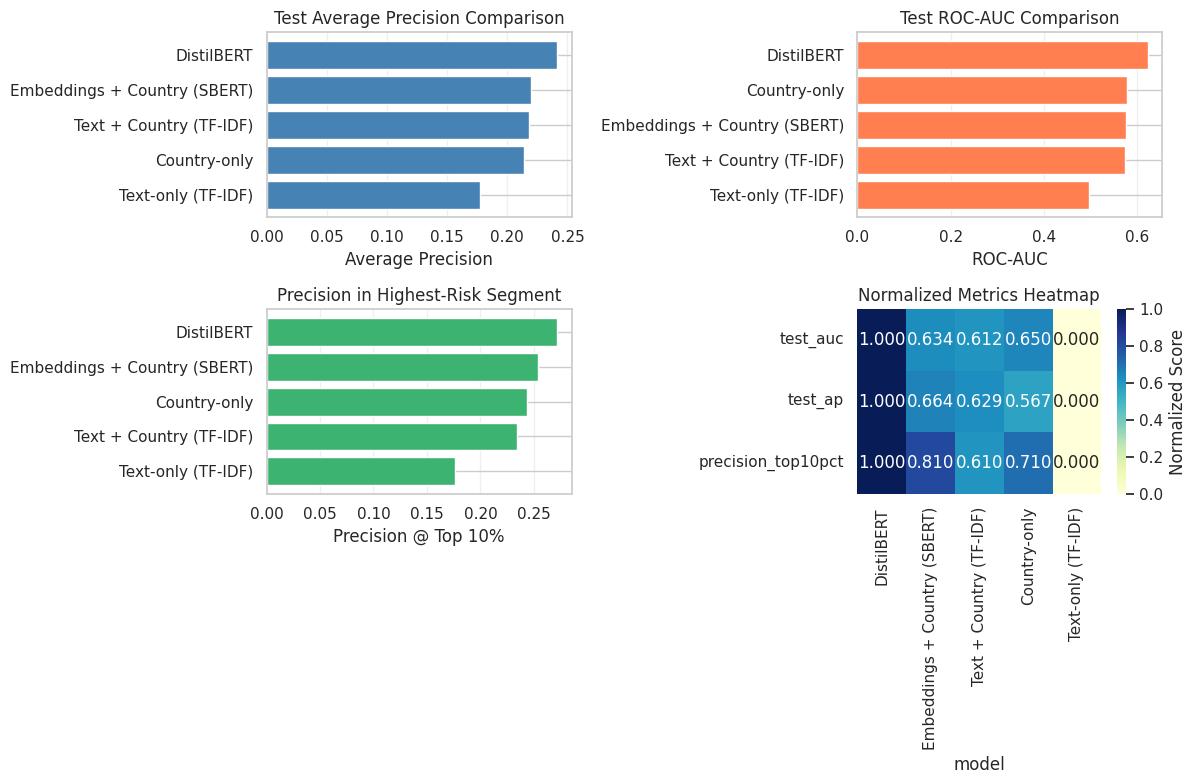

In [ ]:
# Visualization (if matplotlib available)
if PLOTTING_AVAILABLE:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print("\nGenerating comparison plots...")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # AP comparison
    ax = axes[0, 0]
    plot_data = all_results_df.sort_values('test_ap', ascending=True)
    ax.barh(plot_data['model'], plot_data['test_ap'], color='steelblue')
    ax.set_xlabel('Average Precision')
    ax.set_title('Test Average Precision Comparison')
    ax.grid(axis='x', alpha=0.3)
    
    # AUC comparison
    ax = axes[0, 1]
    plot_data = all_results_df.sort_values('test_auc', ascending=True)
    ax.barh(plot_data['model'], plot_data['test_auc'], color='coral')
    ax.set_xlabel('ROC-AUC')
    ax.set_title('Test ROC-AUC Comparison')
    ax.grid(axis='x', alpha=0.3)
    
    # Precision@top10%
    ax = axes[1, 0]
    plot_data = all_results_df.sort_values('precision_top10pct', ascending=True)
    ax.barh(plot_data['model'], plot_data['precision_top10pct'], color='mediumseagreen')
    ax.set_xlabel('Precision @ Top 10%')
    ax.set_title('Precision in Highest-Risk Segment')
    ax.grid(axis='x', alpha=0.3)
    
    # All metrics heatmap
    ax = axes[1, 1]
    heatmap_data = all_results_df[['model', 'test_auc', 'test_ap', 'precision_top10pct']].set_index('model')
    heatmap_data = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())  # Normalize
    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Normalized Score'})
    ax.set_title('Normalized Metrics Heatmap')
    
    plt.tight_layout()
    plot_path = str(FIG_DIR / 'model_comparison_all_plots.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"âœ“ Saved comparison plots: {plot_path}")
    plt.show()
else:
    print("âŠ˜ Plotting not available (matplotlib not installed)")

## Section 8: Error Analysis and Sample Inspection

Inspect model disagreements and examples of high-confidence predictions.

In [19]:
# Disagreement analysis between baseline and DistilBERT
print("\n" + "="*80)
print("ERROR ANALYSIS: Baseline vs DistilBERT Disagreement")
print("="*80)

# Use best baseline model for comparison
best_baseline_idx = baseline_df['test_ap'].idxmax()
best_baseline_name = baseline_df.loc[best_baseline_idx, 'model']

# Get baseline predictions
baseline_predictions_df = df_baseline_out[[IDCOL, CTRYCOL, PRODCOL, YCOL]].copy()
distilbert_predictions_df = distilbert_out[[IDCOL, CTRYCOL, PRODCOL, YCOL, 'p_hat_distilbert']].copy()

# Map best baseline column
if "p_country" in df_baseline_out.columns:
    p_baseline = df_baseline_out['p_country'].values
elif "p_text" in df_baseline_out.columns:
    p_baseline = df_baseline_out['p_text'].values
elif "p_text_country" in df_baseline_out.columns:
    p_baseline = df_baseline_out['p_text_country'].values
elif "p_emb_country" in df_baseline_out.columns:
    p_baseline = df_baseline_out['p_emb_country'].values
else:
    p_baseline = df_baseline_out.iloc[:, -1].values

y_test = df_test[YCOL].values

# Predictions (binary at 0.5 threshold)
pred_baseline = (p_baseline >= 0.5).astype(int)
pred_distilbert = (p_hat_distilbert >= 0.5).astype(int)

# Disagreements
disagreements = (pred_baseline != pred_distilbert)
n_disagree = disagreements.sum()
pct_disagree = 100.0 * n_disagree / len(y_test)

print(f"\nDisagreement Summary:")
print(f"  Total test samples: {len(y_test):,}")
print(f"  Disagreements: {n_disagree:,} ({pct_disagree:.1f}%)")

# Among disagreements, how many are correct?
if n_disagree > 0:
    correct_baseline_disagree = (y_test[disagreements] == pred_baseline[disagreements]).sum()
    correct_distilbert_disagree = (y_test[disagreements] == pred_distilbert[disagreements]).sum()
    print(f"\n  Among disagreements:")
    print(f"    Baseline correct: {correct_baseline_disagree:,}")
    print(f"    DistilBERT correct: {correct_distilbert_disagree:,}")
    if correct_distilbert_disagree > correct_baseline_disagree:
        print(f"    â†’ DistilBERT wins {correct_distilbert_disagree - correct_baseline_disagree} more instances")
    else:
        print(f"    â†’ Baseline wins {correct_baseline_disagree - correct_distilbert_disagree} more instances")

print(f"\nâœ“ Error analysis complete")


ERROR ANALYSIS: Baseline vs DistilBERT Disagreement

Disagreement Summary:
  Total test samples: 10,404
  Disagreements: 3,473 (33.4%)

  Among disagreements:
    Baseline correct: 1,008
    DistilBERT correct: 2,465
    â†’ DistilBERT wins 1457 more instances

âœ“ Error analysis complete


## Section 9: Model and Artifact Export

Save all trained models, predictions, and metrics for downstream analysis.

In [20]:
print("\n" + "="*80)
print("EXPORTING MODELS AND ARTIFACTS")
print("="*80)

# 1. Save baseline sklearn models (optional: joblib)
import pickle
baseline_models_path = CLEAN_OUT / 'baseline_models.pkl'
baseline_models_dict = {
    'country': country_pipe,
    'text': best_text,
    'text_country': best_tc,
}
if SBERT_AVAILABLE and res_emb is not None:
    baseline_models_dict['sbert'] = best_emb

with open(baseline_models_path, 'wb') as f:
    pickle.dump(baseline_models_dict, f)
print(f"âœ“ Saved baseline sklearn models: {baseline_models_path}")

# 2. Save DistilBERT model
distilbert_model_path = DISTILBERT_OUT / 'final_model'
trainer.save_model(str(distilbert_model_path))
print(f"âœ“ Saved DistilBERT model: {distilbert_model_path}")

# 3. Save tokenizer
tokenizer.save_pretrained(str(DISTILBERT_OUT / 'tokenizer'))
print(f"âœ“ Saved DistilBERT tokenizer")

# 4. Save all predictions (already done above)
print(f"âœ“ Test predictions saved:")
print(f"  - Baseline: {baseline_out_path}")
print(f"  - DistilBERT: {distilbert_out_path}")

# 5. Save comprehensive metrics JSON
import json
metrics_dict = {
    "baseline_models": baseline_df.to_dict('records'),
    "distilbert_model": res_distilbert,
    "all_models": all_results_df.to_dict('records'),
    "metadata": {
        "test_set_size": len(df_test),
        "positive_rate": float(df_test[YCOL].mean()),
        "trained_at": pd.Timestamp.now().isoformat(),
        "seed": SEED,
        "distilbert_model_name": DISTILBERT_MODEL_NAME,
        "distilbert_epochs": DISTILBERT_FINETUNE_EPOCHS,
    }
}

metrics_json_path = CLEAN_OUT / 'comprehensive_metrics.json'
with open(metrics_json_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, default=str)
print(f"âœ“ Saved comprehensive metrics: {metrics_json_path}")

# 6. Summary of outputs
print("\n" + "="*80)
print("SUMMARY OF OUTPUTS")
print("="*80)
print(f"\nModel artifacts:")
print(f"  - Baseline models (sklearn): {baseline_models_path}")
print(f"  - DistilBERT model: {distilbert_model_path}")
print(f"  - Tokenizer: {DISTILBERT_OUT / 'tokenizer'}")

print(f"\nPredictions:")
print(f"  - Baseline predictions: {baseline_out_path}")
print(f"  - DistilBERT predictions: {distilbert_out_path}")

print(f"\nMetrics & Comparison:")
print(f"  - All models comparison: {comparison_out_path}")
print(f"  - Comprehensive metrics: {metrics_json_path}")

print(f"\nVisualization:")
if PLOTTING_AVAILABLE:
    print(f"  - Comparison plots: {plot_path}")
else:
    print(f"  - Comparison plots: (not generated)")

print(f"\nâœ“ All artifacts exported to: {CLEAN_OUT}")
print("\nâœ“ ANALYSIS COMPLETE")


EXPORTING MODELS AND ARTIFACTS
âœ“ Saved baseline sklearn models: /content/drive/MyDrive/Project/data/cleaned_data/baseline_models.pkl
âœ“ Saved DistilBERT model: /content/drive/MyDrive/Project/data/cleaned_data/distilbert_run/final_model
âœ“ Saved DistilBERT tokenizer
âœ“ Test predictions saved:
  - Baseline: /content/drive/MyDrive/Project/data/cleaned_data/test_predictions_all_models.csv
  - DistilBERT: /content/drive/MyDrive/Project/data/cleaned_data/pred_distilbert_oos.csv
âœ“ Saved comprehensive metrics: /content/drive/MyDrive/Project/data/cleaned_data/comprehensive_metrics.json

SUMMARY OF OUTPUTS

Model artifacts:
  - Baseline models (sklearn): /content/drive/MyDrive/Project/data/cleaned_data/baseline_models.pkl
  - DistilBERT model: /content/drive/MyDrive/Project/data/cleaned_data/distilbert_run/final_model
  - Tokenizer: /content/drive/MyDrive/Project/data/cleaned_data/distilbert_run/tokenizer

Predictions:
  - Baseline predictions: /content/drive/MyDrive/Project/data/cleaned

---

## Appendix: Quick Reference

### Running This Notebook

**Recommended execution order:**
1. Sections 1â€“4: Setup, imports, configuration, data loading
2. Section 5: Baseline models (non-blocking; can run independently)
3. Section 6: DistilBERT training (computationally intensive; best on GPU)
4. Sections 7â€“10: Evaluation, comparison, visualization, export

### Output Files

Non-figure outputs are saved to `data/cleaned_data/`:
- **Model artifacts**: `baseline_models.pkl`, `distilbert_run/`
- **Predictions**: `test_predictions_all_models.csv`, `pred_distilbert_oos.csv`
- **Metrics**: `model_comparison_all.csv`, `comprehensive_metrics.json`, `model_comparison_with_distilbert.csv`

All figures are saved to `fig/`:
- **Main comparison plots**: `model_comparison_all_plots.png`
- **Stage 8 plots**: `fig_pr_curve_baseline_vs_distilbert.png`, `fig_roc_curve_baseline_vs_distilbert.png`, `fig_precision_top10_bar_baseline_vs_distilbert.png`, `fig_score_distribution_best_baseline_vs_distilbert.png`
- **Appendix plots**: `fig_step1_notifications_over_time.png`, `fig_step2_import_dynamics_by_exporter.png`, `fig_step3_exposure_over_time.png`, `fig_step4_label_rate_by_exporter.png`

### Modifying Hyperparameters

Edit cells in **Section 3** to change:
- `DISTILBERT_FINETUNE_EPOCHS`: number of fine-tune epochs
- `DISTILBERT_LR`: learning rate
- `BASELINE_TOP_PCT`: threshold for Precision@top_X%
- Time boundaries (`PRETRAIN_END`, `FINETUNE_START`, etc.)

### Troubleshooting

- **CUDA out of memory**: Reduce `DISTILBERT_BATCH_TRAIN`
- **SBERT not available**: Install with `pip install sentence-transformers`
- **Slow baseline training**: Reduce `BASELINE_CV_SPLITS` or use fewer hyperparameter combinations

---

**Created**: Unified pipeline merging Stage 5 (Baseline) and Stage 6 (DistilBERT)  
**Compatibility**: Python 3.8+, PyTorch, scikit-learn, transformers

## Section 10: Visualization

This section reproduces the Stage 8 poster figures directly inside the master pipeline, using outputs from baseline and DistilBERT runs.

Inputs:
- data/cleaned_data/test_predictions_all_models.csv
- data/cleaned_data/pred_distilbert_oos.csv

Outputs:
- model_comparison_with_distilbert.csv
- fig_pr_curve_baseline_vs_distilbert.png
- fig_roc_curve_baseline_vs_distilbert.png
- fig_precision_top10_bar_baseline_vs_distilbert.png
- fig_score_distribution_best_baseline_vs_distilbert.png

In [21]:
# Stage 8 setup: load baseline and DistilBERT predictions
BASELINE_PATH = CLEAN_OUT / 'test_predictions_all_models.csv'
DISTIL_PATH = CLEAN_OUT / 'pred_distilbert_oos.csv'

print('Baseline file exists:', BASELINE_PATH.exists())
print('DistilBERT file exists:', DISTIL_PATH.exists())

baseline = pd.read_csv(BASELINE_PATH, dtype={'hs4': str})
distil = pd.read_csv(DISTIL_PATH, dtype={'hs4': str})

# Standardize date key
for frame in (baseline, distil):
    if 'distribution_date' in frame.columns:
        frame['distribution_date'] = pd.to_datetime(
            frame['distribution_date'], errors='coerce', utc=True
        ).dt.date

# Standardize HS4 key when present
for frame in (baseline, distil):
    if 'hs4' in frame.columns:
        frame['hs4'] = frame['hs4'].astype(str).str.zfill(4)

FULL_KEYS = ['notified_document', 'country', 'hs4', 'distribution_date']
DATE_KEY = ['distribution_date']

base_cols = [
    c for c in ['Y_struct_abn', 'p_country', 'p_text', 'p_text_country', 'p_emb_country']
    if c in baseline.columns
]
dist_cols = [c for c in ['Y_struct_abn', 'Y_n', 'p_hat_distilbert'] if c in distil.columns]

if not set(FULL_KEYS).issubset(baseline.columns):
    raise ValueError(
        f"Baseline file is missing required keys {FULL_KEYS}. Found: {baseline.columns.tolist()}"
    )

baseline = baseline[FULL_KEYS + base_cols].copy()

# Case 1: Distil file has the same keys as baseline
if set(FULL_KEYS).issubset(distil.columns):
    distil = distil[FULL_KEYS + dist_cols].copy()
    viz_df = baseline.merge(distil, on=FULL_KEYS, how='inner', suffixes=('_base', '_distil'))

# Case 2: Distil file is date-level only (no document-country-hs4 keys)
elif set(DATE_KEY).issubset(distil.columns):
    print(
        'Warning: DistilBERT predictions are date-level only. '
        'Aggregating DistilBERT to one score per date and merging on distribution_date.'
    )

    distil_date = distil[DATE_KEY + dist_cols].copy()
    agg_map = {}
    if 'p_hat_distilbert' in distil_date.columns:
        agg_map['p_hat_distilbert'] = 'mean'
    if 'Y_struct_abn' in distil_date.columns:
        agg_map['Y_struct_abn'] = 'max'
    if 'Y_n' in distil_date.columns:
        agg_map['Y_n'] = 'max'

    if not agg_map:
        raise ValueError(
            f"Distil file does not contain expected score/label columns. Found: {distil.columns.tolist()}"
        )

    distil_date = distil_date.groupby('distribution_date', as_index=False).agg(agg_map)
    viz_df = baseline.merge(distil_date, on='distribution_date', how='inner', suffixes=('_base', '_distil'))

else:
    raise ValueError(
        'Distil file schema is incompatible. '
        f"Expected either full keys {FULL_KEYS} or date key {DATE_KEY}. "
        f"Found: {distil.columns.tolist()}"
    )

# Harmonize binary label
if 'Y_struct_abn_distil' in viz_df.columns and 'Y_struct_abn_base' in viz_df.columns:
    viz_df['Y'] = viz_df['Y_struct_abn_distil'].fillna(viz_df['Y_struct_abn_base'])
elif 'Y_struct_abn' in viz_df.columns:
    viz_df['Y'] = viz_df['Y_struct_abn']
elif 'Y_n' in viz_df.columns:
    viz_df['Y'] = viz_df['Y_n']
else:
    raise ValueError('No label column found after merge.')

viz_df['Y'] = pd.to_numeric(viz_df['Y'], errors='coerce').fillna(0).astype(int)

print('Merged sample shape:', viz_df.shape)
print('Positive rate:', round(viz_df['Y'].mean(), 4))

Baseline file exists: True
DistilBERT file exists: True
Merged sample shape: (10404, 12)
Positive rate: 0.1795


In [22]:
# Stage 8 metrics and model map
score_cols = {
    'Country-only': 'p_country',
    'TF-IDF text-only': 'p_text',
    'TF-IDF + country': 'p_text_country',
    'SBERT + country': 'p_emb_country',
    'DistilBERT': 'p_hat_distilbert',
}

available_models = {name: col for name, col in score_cols.items() if col in viz_df.columns}
print('Available models:', available_models)

rows = []
for name, col in available_models.items():
    d = viz_df[['Y', col]].dropna()
    y = d['Y'].values
    p = d[col].values

    k = max(1, int(np.ceil(0.10 * len(d))))
    top_idx = np.argsort(-p)[:k]
    precision_top10 = y[top_idx].mean()

    rows.append({
        'model': name,
        'n': len(d),
        'roc_auc': roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        'avg_precision': average_precision_score(y, p),
        'precision_top10pct': precision_top10
    })

metrics_df_stage8 = pd.DataFrame(rows).sort_values('avg_precision', ascending=False)
metrics_df_stage8.to_csv(CLEAN_OUT / 'model_comparison_with_distilbert.csv', index=False)
metrics_df_stage8

Available models: {'Country-only': 'p_country', 'TF-IDF text-only': 'p_text', 'TF-IDF + country': 'p_text_country', 'SBERT + country': 'p_emb_country', 'DistilBERT': 'p_hat_distilbert'}


,model,n,roc_auc,avg_precision,precision_top10pct
4,DistilBERT,10404,0.622366,0.241499,0.271854
3,SBERT + country,10404,0.576472,0.220016,0.253602
2,TF-IDF + country,10404,0.573708,0.217806,0.234390
0,Country-only,10404,0.578511,0.213848,0.243996
1,TF-IDF text-only,10404,0.497029,0.177574,0.175793


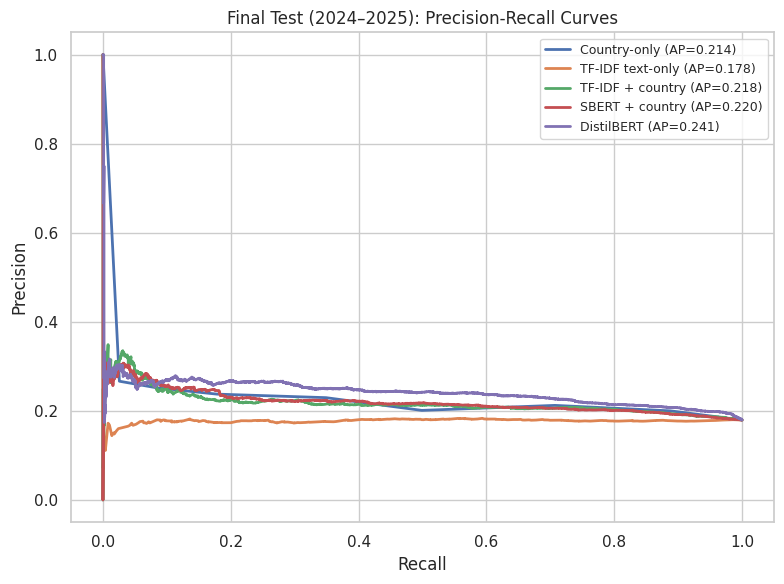

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_pr_curve_baseline_vs_distilbert.png


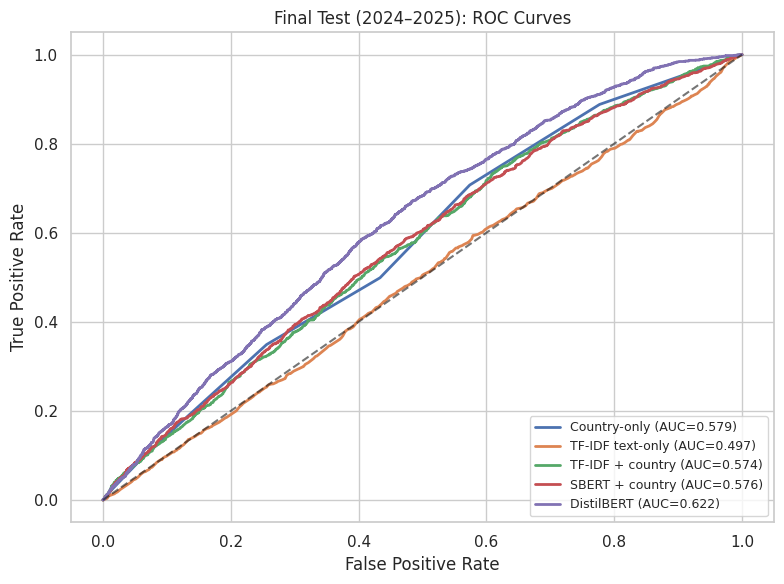

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_roc_curve_baseline_vs_distilbert.png


In [ ]:
# Figure 1: Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, col in available_models.items():
    d = viz_df[['Y', col]].dropna()
    y = d['Y'].values
    p = d[col].values
    pr, re, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    ax.plot(re, pr, lw=2, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Final Test (2024â€“2025): Precision-Recall Curves')
ax.legend(loc='best', fontsize=9)

out = FIG_DIR / 'fig_pr_curve_baseline_vs_distilbert.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

# Figure 2: ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, col in available_models.items():
    d = viz_df[['Y', col]].dropna()
    y = d['Y'].values
    p = d[col].values
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.6)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Final Test (2024â€“2025): ROC Curves')
ax.legend(loc='lower right', fontsize=9)

out = FIG_DIR / 'fig_roc_curve_baseline_vs_distilbert.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

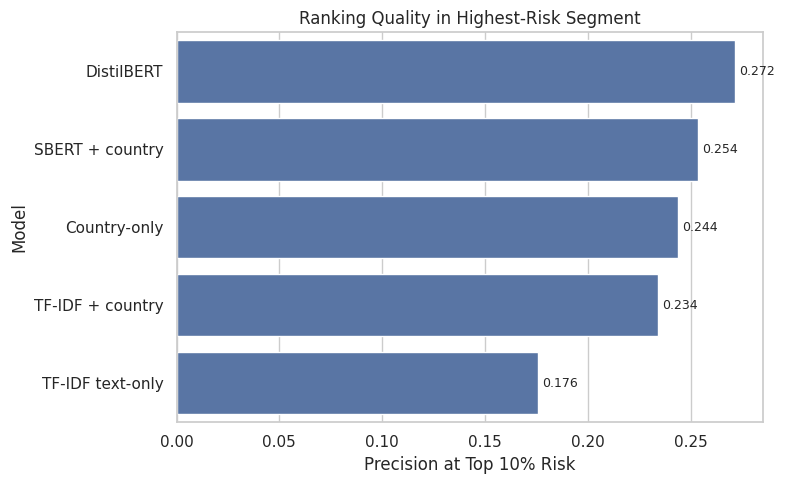

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_precision_top10_bar_baseline_vs_distilbert.png


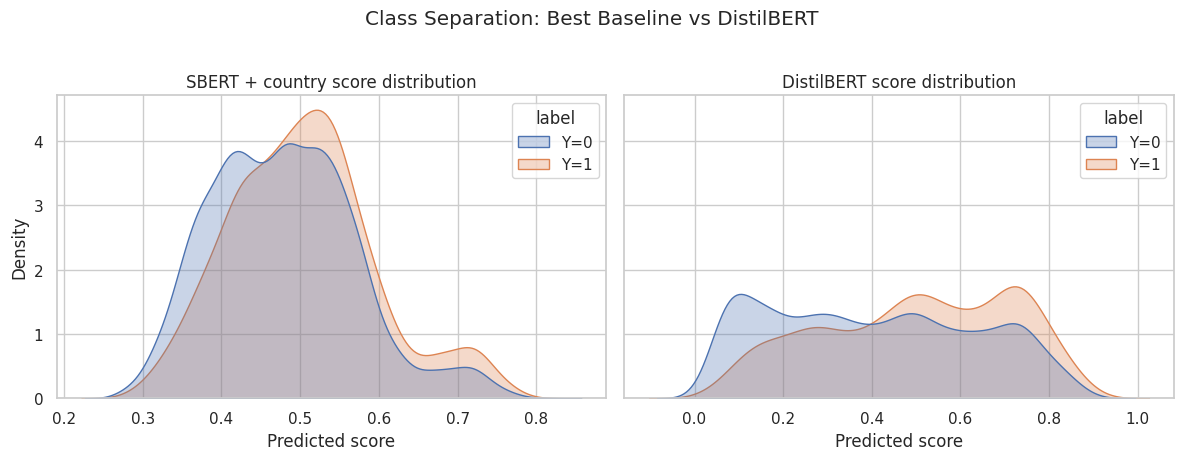

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_score_distribution_best_baseline_vs_distilbert.png


In [ ]:
# Figure 3: Precision@Top10% bar chart
plot_df = metrics_df_stage8.sort_values('precision_top10pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_df, x='precision_top10pct', y='model', ax=ax)
ax.set_xlabel('Precision at Top 10% Risk')
ax.set_ylabel('Model')
ax.set_title('Ranking Quality in Highest-Risk Segment')

for i, v in enumerate(plot_df['precision_top10pct']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

out = FIG_DIR / 'fig_precision_top10_bar_baseline_vs_distilbert.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

# Figure 4: Score distributions (DistilBERT vs best baseline by AP)
best_baseline = metrics_df_stage8.loc[metrics_df_stage8['model'] != 'DistilBERT'].iloc[0]['model'] if (metrics_df_stage8['model'] != 'DistilBERT').any() else None

if best_baseline is None:
    print('No baseline model available for comparison.')
else:
    best_col = available_models[best_baseline]
    distil_col = available_models.get('DistilBERT')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    d1 = viz_df[['Y', best_col]].dropna().copy()
    d1['label'] = d1['Y'].map({0: 'Y=0', 1: 'Y=1'})
    sns.kdeplot(data=d1, x=best_col, hue='label', common_norm=False, fill=True, alpha=0.3, ax=axes[0])
    axes[0].set_title(f'{best_baseline} score distribution')
    axes[0].set_xlabel('Predicted score')

    d2 = viz_df[['Y', distil_col]].dropna().copy()
    d2['label'] = d2['Y'].map({0: 'Y=0', 1: 'Y=1'})
    sns.kdeplot(data=d2, x=distil_col, hue='label', common_norm=False, fill=True, alpha=0.3, ax=axes[1])
    axes[1].set_title('DistilBERT score distribution')
    axes[1].set_xlabel('Predicted score')

    fig.suptitle('Class Separation: Best Baseline vs DistilBERT', y=1.02)
    plt.tight_layout()

    out = FIG_DIR / 'fig_score_distribution_best_baseline_vs_distilbert.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved:', out)

### Stage 8 Appendix Figures from Stages 1â€“4 (Optional)

These are supplementary diagnostics retained from the original Stage 8 notebook.

In [25]:
# Load Step 1â€“4 outputs
step1_path = PROJECT_ROOT / 'data/cleaned_data' / 'us_notif_clean_wide.csv'
step2_path = PROJECT_ROOT / 'data/cleaned_data' / 'usitc_imports_hs4_panel.csv'
step3_path = PROJECT_ROOT / 'data/cleaned_data' / 'hs4_imports_with_notif_exposure.csv'
step4_path = PROJECT_ROOT / 'data/cleaned_data' / 'notif_labels_hs4.csv'

step1 = pd.read_csv(step1_path, dtype=str)
step2 = pd.read_csv(step2_path, dtype={'hs4': str, 'country': str})
step3 = pd.read_csv(step3_path, dtype={'hs4': str, 'country': str})
step4 = pd.read_csv(step4_path, dtype={'hs4': str, 'country': str})

if 'distribution_date' in step1.columns:
    step1['distribution_date'] = pd.to_datetime(step1['distribution_date'], errors='coerce', utc=True)
if 'date' in step2.columns:
    step2['date'] = pd.to_datetime(step2['date'], errors='coerce', utc=True)
if 'date' in step3.columns:
    step3['date'] = pd.to_datetime(step3['date'], errors='coerce', utc=True)
if 'distribution_date' in step4.columns:
    step4['distribution_date'] = pd.to_datetime(step4['distribution_date'], errors='coerce', utc=True)

print('Loaded Step 1 rows:', len(step1))
print('Loaded Step 2 rows:', len(step2))
print('Loaded Step 3 rows:', len(step3))
print('Loaded Step 4 rows:', len(step4))

Loaded Step 1 rows: 5145
Loaded Step 2 rows: 509310
Loaded Step 3 rows: 522855
Loaded Step 4 rows: 52033


/tmp/ipython-input-3778498971.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  s1['year_month'] = s1['distribution_date'].dt.to_period('M').astype(str)


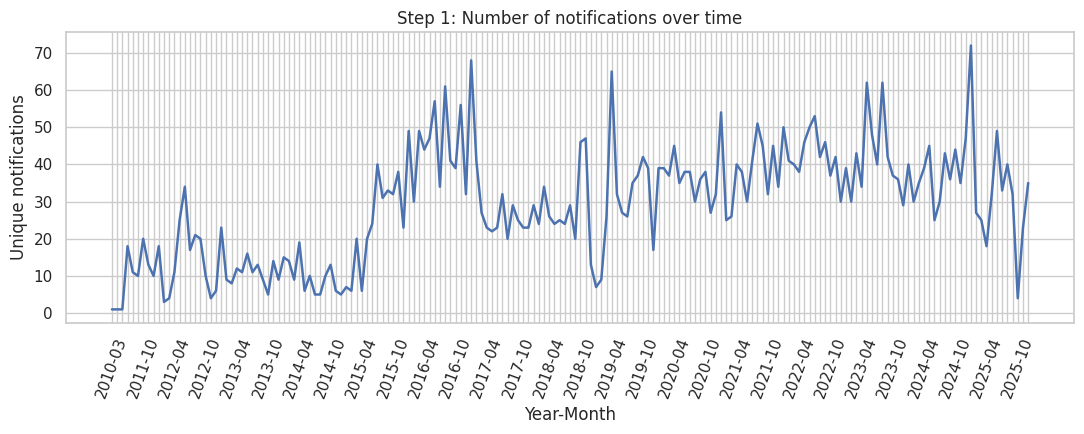

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_step1_notifications_over_time.png


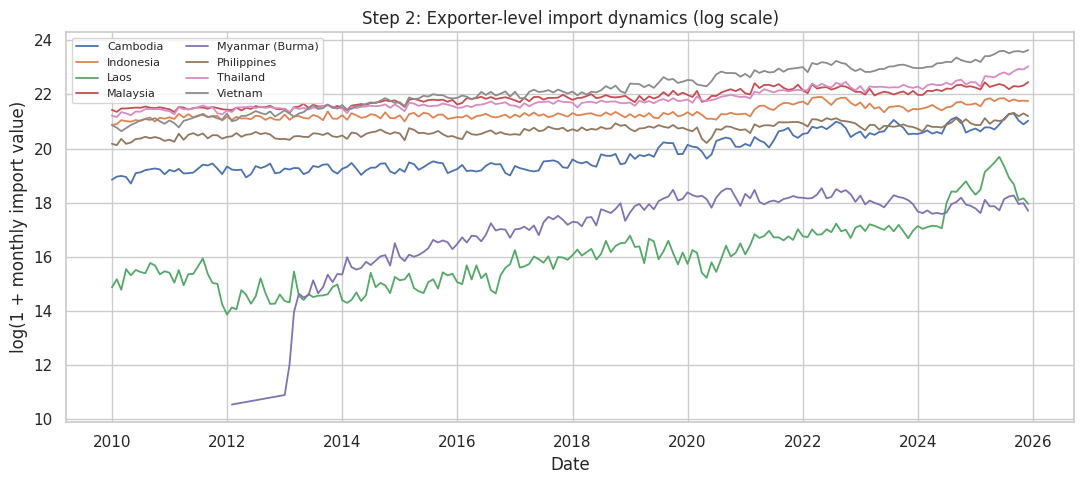

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_step2_import_dynamics_by_exporter.png


In [ ]:
# Figure S1 (Step 1): Notifications over time
s1 = step1.dropna(subset=['distribution_date']).copy()
s1['year_month'] = s1['distribution_date'].dt.to_period('M').astype(str)
notif_ts = s1.groupby('year_month', as_index=False)['notified_document'].nunique()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(notif_ts['year_month'], notif_ts['notified_document'], lw=1.8)
ax.set_title('Step 1: Number of notifications over time')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Unique notifications')
ax.tick_params(axis='x', rotation=70)
for i, label in enumerate(ax.get_xticklabels()):
    if i % 6 != 0:
        label.set_visible(False)

out = FIG_DIR / 'fig_step1_notifications_over_time.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

# Figure S2 (Step 2): Monthly import dynamics by exporter
s2 = step2.dropna(subset=['date', 'country', 'import_value']).copy()
trade_ts = s2.groupby(['date', 'country'], as_index=False)['import_value'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
for country, g in trade_ts.groupby('country'):
    g = g.sort_values('date')
    ax.plot(g['date'], np.log1p(g['import_value']), lw=1.3, label=country)

ax.set_title('Step 2: Exporter-level import dynamics (log scale)')
ax.set_xlabel('Date')
ax.set_ylabel('log(1 + monthly import value)')
ax.legend(ncol=2, fontsize=8)

out = FIG_DIR / 'fig_step2_import_dynamics_by_exporter.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

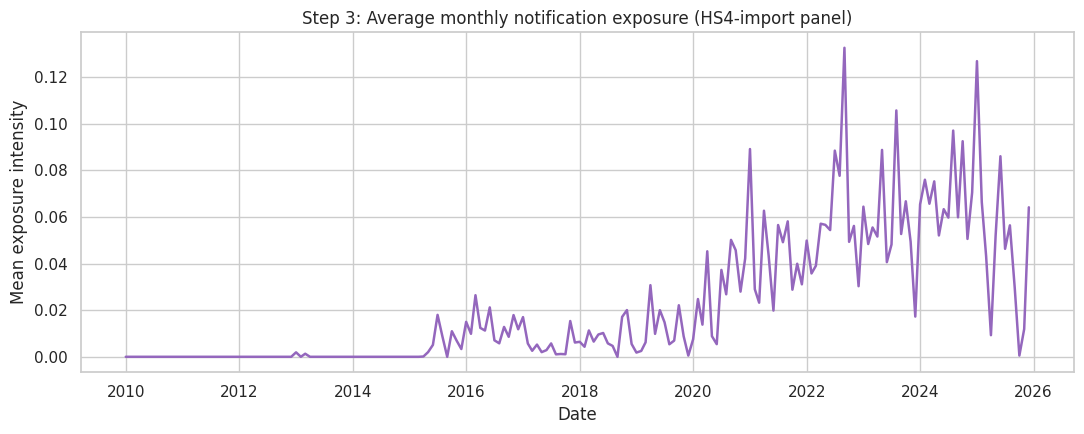

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_step3_exposure_over_time.png


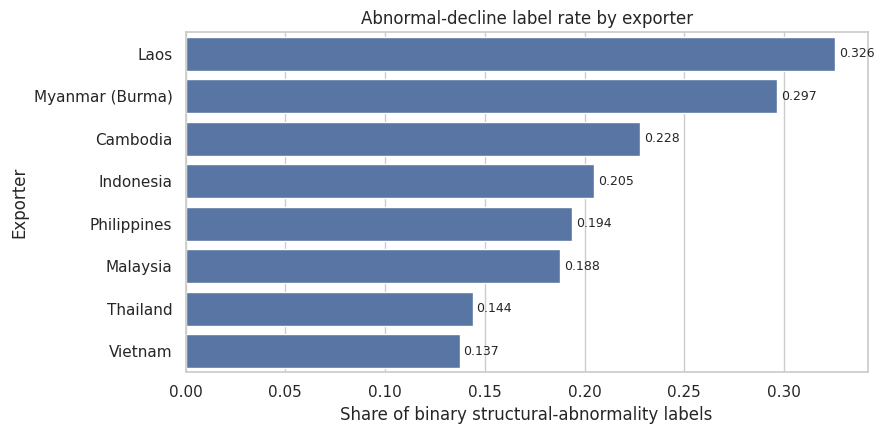

Saved: /content/drive/MyDrive/Project/data/cleaned_data/fig_step4_label_rate_by_exporter.png


In [ ]:
# Figure S3 (Step 3): Notification exposure intensity over time
s3 = step3.dropna(subset=['date']).copy()
if 'exposure_w' not in s3.columns:
    raise ValueError('exposure_w column not found in Step 3 output')

exp_ts = s3.groupby('date', as_index=False)['exposure_w'].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(exp_ts['date'], exp_ts['exposure_w'], lw=1.8, color='tab:purple')
ax.set_title('Step 3: Average monthly notification exposure (HS4-import panel)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean exposure intensity')

out = FIG_DIR / 'fig_step3_exposure_over_time.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

# Figure S4 (Step 4): Label prevalence by exporter
s4 = step4.copy()
if 'Y_struct_abn' not in s4.columns:
    raise ValueError('Y_struct_abn column not found in Step 4 output')

s4['Y_struct_abn'] = pd.to_numeric(s4['Y_struct_abn'], errors='coerce')
label_by_exporter = s4.dropna(subset=['country', 'Y_struct_abn']).groupby('country', as_index=False)['Y_struct_abn'].mean()
label_by_exporter = label_by_exporter.sort_values('Y_struct_abn', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=label_by_exporter, x='Y_struct_abn', y='country', ax=ax)
ax.set_title('Abnormal-decline label rate by exporter')
ax.set_xlabel('Share of binary structural-abnormality labels')
ax.set_ylabel('Exporter')

for i, v in enumerate(label_by_exporter['Y_struct_abn']):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

out = FIG_DIR / 'fig_step4_label_rate_by_exporter.png'
plt.tight_layout()
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)

---

## Appendix: Quick Reference

### Running This Notebook

**Recommended execution order:**
1. Sections 1â€“4: Setup, imports, configuration, data loading
2. Section 5: Baseline models (non-blocking; can run independently)
3. Section 6: DistilBERT training (computationally intensive; best on GPU)
4. Sections 7â€“10: Evaluation, comparison, visualization, export

### Output Files

Non-figure outputs are saved to `data/cleaned_data/`:
- **Model artifacts**: `baseline_models.pkl`, `distilbert_run/`
- **Predictions**: `test_predictions_all_models.csv`, `pred_distilbert_oos.csv`
- **Metrics**: `model_comparison_all.csv`, `comprehensive_metrics.json`, `model_comparison_with_distilbert.csv`

All figures are saved to `fig/`:
- **Main comparison plots**: `model_comparison_all_plots.png`
- **Stage 8 plots**: `fig_pr_curve_baseline_vs_distilbert.png`, `fig_roc_curve_baseline_vs_distilbert.png`, `fig_precision_top10_bar_baseline_vs_distilbert.png`, `fig_score_distribution_best_baseline_vs_distilbert.png`
- **Appendix plots**: `fig_step1_notifications_over_time.png`, `fig_step2_import_dynamics_by_exporter.png`, `fig_step3_exposure_over_time.png`, `fig_step4_label_rate_by_exporter.png`

### Modifying Hyperparameters

Edit cells in **Section 3** to change:
- `DISTILBERT_FINETUNE_EPOCHS`: number of fine-tune epochs
- `DISTILBERT_LR`: learning rate
- `BASELINE_TOP_PCT`: threshold for Precision@top_X%
- Time boundaries (`PRETRAIN_END`, `FINETUNE_START`, etc.)

### Troubleshooting

- **CUDA out of memory**: Reduce `DISTILBERT_BATCH_TRAIN`
- **SBERT not available**: Install with `pip install sentence-transformers`
- **Slow baseline training**: Reduce `BASELINE_CV_SPLITS` or use fewer hyperparameter combinations

---

**Created**: Unified pipeline merging Stage 5 (Baseline) and Stage 6 (DistilBERT)  
**Compatibility**: Python 3.8+, PyTorch, scikit-learn, transformers